In [1]:
from pathlib import Path
import pandas as pd
import kagglehub
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights
import torch.nn.functional as F
import collections
from PIL import Image
import matplotlib.pyplot as plt
import scripts.data_preparation
import scripts.training
import scripts.models
import scripts.prediction
import scripts.plot
import scripts.datasets


/home/adrian/miniconda3/envs/openclip/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data preparation

### Creating a DataFrame

In [2]:
path_text = Path(kagglehub.dataset_download("youssefaboelnasr/flickr8k-text"))
path_image = Path(kagglehub.dataset_download("adityajn105/flickr8k"))

df, image_dir = scripts.data_preparation.create_df(path_text=path_text,
                                        path_image=path_image)
df.head()

,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...


#### Check Dataintegrity

In [3]:
scripts.data_preparation.filter_existing_image(image_dir= image_dir,
                                               df = df)

Remaining rows: 40455
Remaining unique images: 8091
['1000268201_693b08cb0e.jpg', '1000268201_693b08cb0e.jpg', '1000268201_693b08cb0e.jpg', '1000268201_693b08cb0e.jpg', '1000268201_693b08cb0e.jpg', '1001773457_577c3a7d70.jpg', '1001773457_577c3a7d70.jpg', '1001773457_577c3a7d70.jpg', '1001773457_577c3a7d70.jpg', '1001773457_577c3a7d70.jpg', '1002674143_1b742ab4b8.jpg', '1002674143_1b742ab4b8.jpg', '1002674143_1b742ab4b8.jpg', '1002674143_1b742ab4b8.jpg', '1002674143_1b742ab4b8.jpg', '1003163366_44323f5815.jpg', '1003163366_44323f5815.jpg', '1003163366_44323f5815.jpg', '1003163366_44323f5815.jpg', '1003163366_44323f5815.jpg']
Empty DataFrame
Columns: [image, caption]
Index: []
Problematische Namen: 0


In [4]:
df.shape, df['image'].nunique()

((40460, 2), 8092)

### Add ImageID Column through the DataFrame

In [5]:
df = scripts.data_preparation.add_image_ids(df)
df.head()

,image,caption,image_id
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...,0
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .,0
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .,0
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...,0
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...,0


### Optional: Create a smaller subset for faster experiments

In [6]:
df = scripts.data_preparation.create_small_dataset(df,
                                                   num_images=500)

### Creating a DataFrame for Train and Test

In [7]:
df_train, df_test, train_images, test_images = scripts.data_preparation.create_image_level_train_test_split(df = df)

/home/adrian/Nextcloud/Documents/Studium/XTut/Clip_resnet_training/scripts/data_preparation.py:86: UserWarning: you are shuffling a 'StringArray' object which is not a subclass of 'Sequence'; `shuffle` is not guaranteed to behave correctly. E.g., non-numpy array/tensor objects with view semantics may contain duplicates after shuffling.
  rng.shuffle(unique_images)


### Creating image preprocessing pipeline

In [8]:
image_size = 224

preprocess = transforms.Compose([transforms.Resize((image_size,image_size)),
                                transforms.ToTensor(),
                                transforms.Normalize(
                                     mean=[0.485, 0.456, 0.406],
                                     std=[0.229, 0.224, 0.225]
                                )])

### Building vocabulary

In [9]:
vocab, counter = scripts.data_preparation.create_vocab(df_train=df_train)
vocab, counter

({'<pad>': 0,
  '<unk>': 1,
  'a': 2,
  'person': 3,
  'eats': 4,
  'while': 5,
  'watching': 6,
  'small': 7,
  'television': 8,
  '.': 9,
  'sits': 10,
  'on': 11,
  'the': 12,
  'floor': 13,
  'and': 14,
  'in': 15,
  'front': 16,
  'of': 17,
  'with': 18,
  'picture': 19,
  'girl': 20,
  'it': 21,
  'young': 22,
  'man': 23,
  'by': 24,
  'food': 25,
  'meal': 26,
  'him': 27,
  'someone': 28,
  'is': 29,
  'laying': 30,
  'eating': 31,
  'brown': 32,
  'shirt': 33,
  'dark': 34,
  'shorts': 35,
  'plays': 36,
  'beach': 37,
  'his': 38,
  'two': 39,
  'black': 40,
  'dogs': 41,
  'holds': 42,
  'ball': 43,
  'throwing': 44,
  'toy': 45,
  'at': 46,
  'playing': 47,
  'boy': 48,
  'blue': 49,
  'slides': 50,
  'down': 51,
  'slide': 52,
  'into': 53,
  'pool': 54,
  'swimming': 55,
  'trunks': 56,
  'yellow': 57,
  'wading': 58,
  'inflatable': 59,
  'toys': 60,
  'floating': 61,
  'water': 62,
  'rides': 63,
  'backyard': 64,
  'sliding': 65,
  'colorful': 66,
  'child': 67,
  'fa

### Creating directory for models

In [10]:
BATCH_SIZE = 32
checkpoint_path, best_model_path = scripts.data_preparation.create_model_directory(path = "Models/clip_bs",
                                                batch_size=BATCH_SIZE)

In [11]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

## Training

### Check if a Train Checkpoint exist

In [12]:
if checkpoint_path.exists():
        checkpoint, vocab, image_encoder, text_encoder, optimizer, losses, best_score, start_epoch = scripts.models.load_model(checkpoint_path,
                                                                                                                               device)
        print(f"Loaded checkpoint from epoch {start_epoch}")
else:
    
    image_encoder = scripts.models.ImageEncoder().to(device)
    text_encoder = scripts.models.TextEncoder(len(vocab)).to(device)
    image_encoder.train()
    text_encoder.train()
    optimizer = torch.optim.Adam(
    list(image_encoder.projection.parameters())+
    list(text_encoder.parameters()),
    lr = 1e-3)

    losses = []
    best_score = 0.0
    start_epoch = 0
    print("No checkpoint found. Start from scratch.")

Loaded checkpoint from epoch 6


### Converting captions into token IDs

In [13]:
tokenizer = scripts.data_preparation.SimpleTokenizer(vocab = vocab)
tokenizer('dog , bird house cage')

tensor([ 26,  97, 802, 495,   1,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0])

### Creating train- and test datasets

In [14]:
train_dataset = scripts.datasets.FlickrDataset(df = df_train,
                        image_dir = image_dir,
                        preprocess = preprocess,
                        tokenizer = tokenizer
                        )
test_dataset = scripts.datasets.FlickrDataset(df = df_test,
                        image_dir = image_dir,
                        preprocess = preprocess,
                        tokenizer = tokenizer
                        )

### Creating train- and test dataloaders

In [15]:
#BATCH_SIZE = 32
NUM_WORKERS = 0

train_dataloader = DataLoader(dataset = train_dataset,
                        batch_size = BATCH_SIZE,
                        num_workers = NUM_WORKERS,
                        shuffle = True)
test_dataloader = DataLoader(dataset = test_dataset,
                        batch_size = BATCH_SIZE,
                        num_workers = NUM_WORKERS,
                        shuffle = True)

In [16]:
image, text, image_id = next(iter(train_dataloader))

image.shape, text.shape, image_id.shape, image_id[:10]

(torch.Size([32, 3, 224, 224]),
 torch.Size([32, 32]),
 torch.Size([32]),
 tensor([2448,  548, 5912, 4708, 2557, 6803,  542, 2778, 2377,  705]))

#### Debugging

In [17]:
batch = next(iter(train_dataloader))
images, texts, image_ids = batch

print("texts min:", texts.min().item())
print("texts max:", texts.max().item())
print("len(vocab):", len(vocab))
print("max vocab id:", max(vocab.values()))
print("embedding size:", text_encoder.embedding.num_embeddings)
print("image_ids shape:", image_ids.shape)

texts min: 0
texts max: 1059
len(vocab): 1102
max vocab id: 1101
embedding size: 1102
image_ids shape: torch.Size([32])


In [18]:
losses = scripts.training.train_eval_loop(train_dataloader=train_dataloader,
                                          test_dataloader=test_dataloader,
                                          optimizer=optimizer,
                                          total_epochs=3,
                                          device=device,
                                          image_encoder=image_encoder,
                                          text_encoder=text_encoder,
                                          best_model_path=best_model_path,
                                          checkpoint_path=checkpoint_path,
                                          vocab=vocab,
                                          best_score=best_score,
                                          start_epoch=start_epoch,
                                          losses=losses)

Epoch: 6 | Avg Loss: 3.1166
Recall@1: 0.0800 | Recall@5: 0.2500 | Recall@10: 0.4200
Epoch: 7 | Avg Loss: 2.1630
Recall@1: 0.1400 | Recall@5: 0.3300 | Recall@10: 0.5100
Saved Checkpoint model under Models/clip_bs32/last_Checkpoint.pt
Epoch: 8 | Avg Loss: 1.4376
Recall@1: 0.0900 | Recall@5: 0.3800 | Recall@10: 0.5800
Saved best mode under Models/clip_bs32/best_model.pt


#### Ploting the Training loss

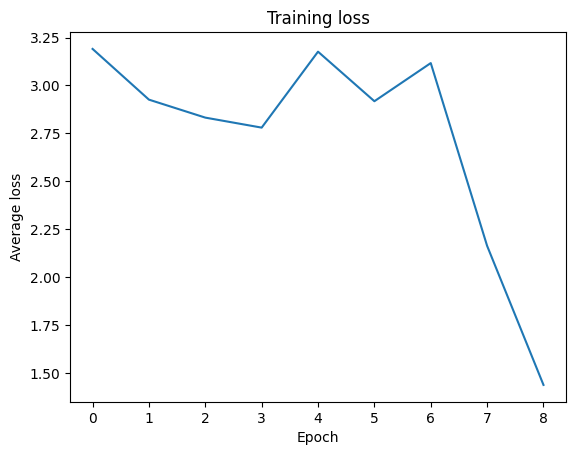

In [19]:
scripts.plot.loss_plot(losses = losses)

### Prediction

In [ ]:
if best_model_path.exists():
    best_model = torch.load(best_model_path, map_location=device)

    image_encoder.load_state_dict(best_model["image_encoder_state_dict"])
    text_encoder.load_state_dict(best_model["text_encoder_state_dict"])

    print(f"Loaded best model from epoch {best_model['epoch']}")
    print(f"Best score: {best_model['best_score']:.4f}")
else:
    print("No best model found.")

Loaded best model from epoch 5
Best score: 0.3600


In [21]:
image_embeddings, text_embeddings, image_ids = scripts.prediction.encode_dataset(image_encoder=image_encoder,
                                                   text_encoder=text_encoder,
                                                   dataloader=test_dataloader,
                                                   device=device)

In [22]:
image_embeddings.shape, text_embeddings.shape

(torch.Size([500, 256]), torch.Size([500, 256]))

In [23]:
logits = image_embeddings@text_embeddings.T
logits.shape

torch.Size([500, 500])

In [24]:
for k in [1, 5, 10]:
    recall = scripts.prediction.recall_at_k_multicaption(
        logits=logits,
        image_ids=image_ids,
        k=k
    )

    print(f"Image-to-Text Recall@{k}: {recall:.4f}")

Image-to-Text Recall@1: 0.1000
Image-to-Text Recall@5: 0.2300
Image-to-Text Recall@10: 0.3500


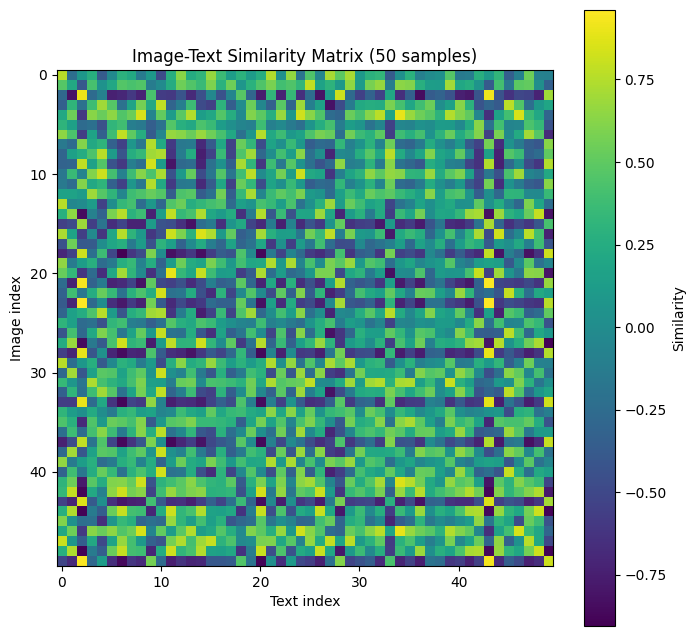

In [25]:
scripts.plot.similarity_matrix(logits=logits,
                  num_images_textes=50)